In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import yaml
from IPython.display import Markdown, display
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from scipy.stats import linregress
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, roc_auc_score, accuracy_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# load yaml
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)
    DATA_PATH = config.get("data_path")
    if DATA_PATH is None:
        print("ERROR: No data path provided")
    USE_DRIVE = bool(config.get("use_drive", False))
# load from drive if requested
if USE_DRIVE:
    from google.colab import drive

    drive.mount('/content/drive')

In [2]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd

def tune_model(estimator, param_grid, X, y, cv, name, X_test=None, y_test=None, scoring='accuracy', n_iter=10, random_state=42):
    # 1. Run RandomizedSearch
    rs = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=n_iter,
        cv=cv,
        scoring=scoring,
        random_state=random_state,
        n_jobs=-1,
        refit=True
    )
    rs.fit(X, y)
    best = rs.best_estimator_
    results = {}

    # 2. Best CV score and params
    results['best_score_cv'] = rs.best_score_
    results['best_params']   = rs.best_params_

    # 3. Full CV results as a DataFrame
    results['cv_results_df'] = pd.DataFrame(rs.cv_results_)

    # 4. If user supplied a test set, evaluate there…
    if X_test is not None and y_test is not None:
        y_pred = best.predict(X_test)
        results['accuracy_test'] = accuracy_score(y_test, y_pred)
        results['class_report_test'] = classification_report(y_test, y_pred, output_dict=True)
        results['confusion_matrix_test'] = confusion_matrix(y_test, y_pred)

    # 5. Feature importances / coefficients
    if hasattr(best, "feature_importances_"):
        results['feature_importances'] = best.feature_importances_
    elif hasattr(best, "coef_"):
        # could be multiclass; shape (n_classes, n_features)
        results['coefficients'] = best.coef_

    # 6. Cross-val on the full data (optional, but shows stability)
    try:
        cv_scores = cross_val_score(best, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        results['cv_scores_full_data'] = cv_scores
        results['cv_scores_mean']      = cv_scores.mean()
        results['cv_scores_std']       = cv_scores.std()
    except Exception as e:
        print(f"Warning: full-data CV failed for {name}: {e}")
        results['cv_scores_full_data'] = None
        results['cv_scores_mean']      = None
        results['cv_scores_std']       = None

    print(f"{name} — best CV {scoring}: {results['best_score_cv']:.4f}")
    if 'accuracy_test' in results:
        print(f"{name} — test accuracy: {results['accuracy_test']:.4f}")

    # 7. Return both the estimator and the collected results
    return best, results


In [14]:
import pandas as pd
import json

def export_tuning_results(window_results, summary_csv_path='window_results_summary.csv', cv_results_csv_path='window_cv_results.csv', metrics=None):
    """
    window_results: dict of the form
        { window_key: {
              'best_model': ...,
              'tuning_results': {
                  'best_params': {...},
                  'best_score_cv': ...,
                  'accuracy_test': ...,
                  'cv_scores_mean': ...,
                  'cv_scores_std': ...,
                  'cv_results_df': pd.DataFrame,
                  ...

    metrics: list of tuning_results keys to pull into the summary CSV.
             Defaults to ['best_score_cv','accuracy_test','cv_scores_mean','cv_scores_std'].
    """
    if metrics is None:
        metrics = ['best_score_cv','accuracy_test','cv_scores_mean','cv_scores_std']

    # ——— Build summary csv ———
    summary_rows = []
    for window, info in window_results.items():
        tr = info['tuning_results']
        row = {'window': window,
               'best_params': json.dumps(tr.get('best_params', {}))}
        for m in metrics:
            row[m] = tr.get(m, None)
        summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(summary_csv_path, index=False)
    print(f"Wrote summary to {summary_csv_path!r} ({len(summary_df)} rows)")

    # ——— Stack all cv_results_df ———
    cv_dfs = []
    for window, info in window_results.items():
        tr = info['tuning_results']
        df_cv = tr.get('cv_results_df')
        if isinstance(df_cv, pd.DataFrame):
            tmp = df_cv.copy()
            tmp['window'] = window
            cv_dfs.append(tmp)

    if cv_dfs:
        all_cv = pd.concat(cv_dfs, ignore_index=True)
        all_cv.to_csv(cv_results_csv_path, index=False)
        print(f"Wrote full CV results to {cv_results_csv_path!r} ({len(all_cv)} rows)")
    else:
        print("No cv_results_df found in any window; skipped writing full CV results.")


# Logistic Regression

In [53]:
from sklearn.model_selection import train_test_split

windows = [1, 3, 5, 10, 15, 20, 30]
window_results = {}

logreg_param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear'],
    'max_iter': [100, 200]
}

for window in windows:
    df = pd.read_csv(os.path.join(DATA_PATH, f"rolling_avg/team_stats_{window}_avg.csv"))

    feature_cols = [col for col in df.columns if col.endswith(f'_avg_{window}')] + ['home']
    df = df.dropna(subset=feature_cols)
    X = df[feature_cols]
    y = df['win']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    best_model, results = tune_model(
        estimator=LogisticRegression(),
        param_grid=logreg_param_grid,
        X=X_train,
        y=y_train,
        cv=5,
        name=f"LogReg_{window}d",
        X_test=X_test,
        y_test=y_test,
        scoring='accuracy',
        n_iter=6,
        random_state=42
    )

    window_results[window] = {
        'best_model': best_model,
        'tuning_results': results
    }

LogReg_1d — best CV accuracy: 0.5922
LogReg_1d — test accuracy: 0.5990
LogReg_3d — best CV accuracy: 0.6107
LogReg_3d — test accuracy: 0.6135
LogReg_5d — best CV accuracy: 0.6234
LogReg_5d — test accuracy: 0.6200
LogReg_10d — best CV accuracy: 0.6373
LogReg_10d — test accuracy: 0.6364
LogReg_15d — best CV accuracy: 0.6467
LogReg_15d — test accuracy: 0.6381
LogReg_20d — best CV accuracy: 0.6506
LogReg_20d — test accuracy: 0.6450
LogReg_30d — best CV accuracy: 0.6572
LogReg_30d — test accuracy: 0.6556


15-20 window size seems to fit the best, 30 games performs even better but that is a lot of games of a season already done...

In [15]:
export_tuning_results(
    window_results,
    summary_csv_path=os.path.join(DATA_PATH, 'prediction_results/lr_window_results_summary.csv'),
    cv_results_csv_path=os.path.join(DATA_PATH, 'prediction_results/lr_window_cv_results.csv'),
    metrics=['best_score_cv','accuracy_test','cv_scores_mean','cv_scores_std']
)

Wrote summary to 'C:/Users/trist/OneDrive/Dokumente/UZH/Semester_6/Intro_Data_Science/Intro_Data_Science_Project/data\\prediction_results/lr_window_results_summary.csv' (7 rows)
Wrote full CV results to 'C:/Users/trist/OneDrive/Dokumente/UZH/Semester_6/Intro_Data_Science/Intro_Data_Science_Project/data\\prediction_results/lr_window_cv_results.csv' (42 rows)


# Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

windows = [1, 3, 5, 10, 15, 20, 30]
window_results = {}

rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
}

for window in windows:
    df = pd.read_csv(os.path.join(DATA_PATH, f"rolling_avg/team_stats_{window}_avg.csv"))

    feature_cols = [c for c in df.columns if c.endswith(f"_avg_{window}")] + ['home']
    df = df.dropna(subset=feature_cols)

    X = df[feature_cols]
    y = df['win']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    best_model, results = tune_model(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=rf_param_grid,
        X=X_train,
        y=y_train,
        cv=5,
        name=f"RF_{window}d",
        X_test=X_test,
        y_test=y_test,
        scoring='accuracy',
        n_iter=8,
        random_state=42
    )

    window_results[window] = {
        'best_model': best_model,
        'tuning_results': results
    }

export_tuning_results(
    window_results,
    summary_csv_path=os.path.join(DATA_PATH, 'prediction_results/rf_window_results_summary.csv'),
    cv_results_csv_path=os.path.join(DATA_PATH, 'prediction_results/rf_window_cv_results.csv'),
    metrics=['best_score_cv','accuracy_test','cv_scores_mean','cv_scores_std']
)


RF_1d — best CV accuracy: 0.5900
RF_1d — test accuracy: 0.5927
RF_3d — best CV accuracy: 0.6031
RF_3d — test accuracy: 0.6084
RF_5d — best CV accuracy: 0.6157
RF_5d — test accuracy: 0.6138
RF_10d — best CV accuracy: 0.6312
RF_10d — test accuracy: 0.6280
RF_15d — best CV accuracy: 0.6395
RF_15d — test accuracy: 0.6354
RF_20d — best CV accuracy: 0.6432
RF_20d — test accuracy: 0.6378
RF_30d — best CV accuracy: 0.6521
RF_30d — test accuracy: 0.6454
Wrote summary to 'C:/Users/trist/OneDrive/Dokumente/UZH/Semester_6/Intro_Data_Science/Intro_Data_Science_Project/data\\prediction_results/rf_window_results_summary.csv' (7 rows)
Wrote full CV results to 'C:/Users/trist/OneDrive/Dokumente/UZH/Semester_6/Intro_Data_Science/Intro_Data_Science_Project/data\\prediction_results/rf_window_cv_results.csv' (56 rows)


# XGBoost

In [17]:
from xgboost import XGBClassifier

windows = [1, 3, 5, 10, 15, 20, 30]
window_results = {}

xgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.3],
}

for window in windows:
    df = pd.read_csv(os.path.join(DATA_PATH, f"rolling_avg/team_stats_{window}_avg.csv"))

    feature_cols = [c for c in df.columns if c.endswith(f"_avg_{window}")] + ['home']
    df = df.dropna(subset=feature_cols)

    X = df[feature_cols]
    y = df['win']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    best_model, results = tune_model(
        estimator=XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42
        ),
        param_grid=xgb_param_grid,
        X=X_train,
        y=y_train,
        cv=5,
        name=f"XGB_{window}d",
        X_test=X_test,
        y_test=y_test,
        scoring='accuracy',
        n_iter=8,
        random_state=42
    )

    window_results[window] = {
        'best_model': best_model,
        'tuning_results': results
    }

export_tuning_results(
    window_results,
    summary_csv_path=os.path.join(DATA_PATH, 'prediction_results/xgb_window_results_summary.csv'),
    cv_results_csv_path=os.path.join(DATA_PATH, 'prediction_results/xgb_window_cv_results.csv'),
    metrics=['best_score_cv','accuracy_test','cv_scores_mean','cv_scores_std']
)


C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGB_1d — best CV accuracy: 0.5903
XGB_1d — test accuracy: 0.5948


C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGB_3d — best CV accuracy: 0.6038
XGB_3d — test accuracy: 0.6114


C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


...

XGB_15d — best CV accuracy: 0.6438
XGB_15d — test accuracy: 0.6352


C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGB_20d — best CV accuracy: 0.6475
XGB_20d — test accuracy: 0.6397


C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGB_30d — best CV accuracy: 0.6530
XGB_30d — test accuracy: 0.6461
Wrote summary to 'C:/Users/trist/OneDrive/Dokumente/UZH/Semester_6/Intro_Data_Science/Intro_Data_Science_Project/data\\prediction_results/xgb_window_results_summary.csv' (7 rows)
Wrote full CV results to 'C:/Users/trist/OneDrive/Dokumente/UZH/Semester_6/Intro_Data_Science/Intro_Data_Science_Project/data\\prediction_results/xgb_window_cv_results.csv' (56 rows)


# Catboost

In [18]:
from catboost import CatBoostClassifier

windows = [1, 3, 5, 10, 15, 20, 30]
window_results = {}

cat_param_grid = {
    'iterations': [100, 200],
    'depth': [4, 6],
    'learning_rate': [0.1, 0.3],
}

for window in windows:
    df = pd.read_csv(os.path.join(DATA_PATH, f"rolling_avg/team_stats_{window}_avg.csv"))

    feature_cols = [c for c in df.columns if c.endswith(f"_avg_{window}")] + ['home']
    df = df.dropna(subset=feature_cols)

    X = df[feature_cols]
    y = df['win']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    best_model, results = tune_model(
        estimator=CatBoostClassifier(
            verbose=0,
            random_seed=42
        ),
        param_grid=cat_param_grid,
        X=X_train,
        y=y_train,
        cv=5,
        name=f"CatBoost_{window}d",
        X_test=X_test,
        y_test=y_test,
        scoring='accuracy',
        n_iter=8,
        random_state=42
    )

    window_results[window] = {
        'best_model': best_model,
        'tuning_results': results
    }

export_tuning_results(
    window_results,
    summary_csv_path=os.path.join(DATA_PATH, 'prediction_results/catboost_window_results_summary.csv'),
    cv_results_csv_path=os.path.join(DATA_PATH, 'prediction_results/catboost_window_cv_results.csv'),
    metrics=['best_score_cv','accuracy_test','cv_scores_mean','cv_scores_std']
)


CatBoost_1d — best CV accuracy: 0.5911
CatBoost_1d — test accuracy: 0.5975
CatBoost_3d — best CV accuracy: 0.6062
CatBoost_3d — test accuracy: 0.6150
CatBoost_5d — best CV accuracy: 0.6225
CatBoost_5d — test accuracy: 0.6173
CatBoost_10d — best CV accuracy: 0.6381
CatBoost_10d — test accuracy: 0.6335


C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
13 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
13 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\catboost\core.py", line 5245, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, ba

CatBoost_15d — best CV accuracy: 0.6475
CatBoost_15d — test accuracy: 0.6430
CatBoost_20d — best CV accuracy: 0.6524
CatBoost_20d — test accuracy: 0.6404
CatBoost_30d — best CV accuracy: 0.6569
CatBoost_30d — test accuracy: 0.6538
Wrote summary to 'C:/Users/trist/OneDrive/Dokumente/UZH/Semester_6/Intro_Data_Science/Intro_Data_Science_Project/data\\prediction_results/catboost_window_results_summary.csv' (7 rows)
Wrote full CV results to 'C:/Users/trist/OneDrive/Dokumente/UZH/Semester_6/Intro_Data_Science/Intro_Data_Science_Project/data\\prediction_results/catboost_window_cv_results.csv' (56 rows)


# LightGBM

In [19]:
from lightgbm import LGBMClassifier

windows = [1, 3, 5, 10, 15, 20, 30]
window_results = {}

lgbm_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 8],
    'learning_rate': [0.05, 0.1],
}

for window in windows:
    df = pd.read_csv(os.path.join(DATA_PATH, f"rolling_avg/team_stats_{window}_avg.csv"))

    feature_cols = [c for c in df.columns if c.endswith(f"_avg_{window}")] + ['home']
    df = df.dropna(subset=feature_cols)

    X = df[feature_cols]
    y = df['win']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    best_model, results = tune_model(
        estimator=LGBMClassifier(random_state=42),
        param_grid=lgbm_param_grid,
        X=X_train,
        y=y_train,
        cv=5,
        name=f"LGBM_{window}d",
        X_test=X_test,
        y_test=y_test,
        scoring='accuracy',
        n_iter=8,              # sample all 8 combos
        random_state=42
    )

    window_results[window] = {
        'best_model': best_model,
        'tuning_results': results
    }

export_tuning_results(
    window_results,
    summary_csv_path=os.path.join(DATA_PATH, 'prediction_results/lgbm_window_results_summary.csv'),
    cv_results_csv_path=os.path.join(DATA_PATH, 'prediction_results/lgbm_window_cv_results.csv'),
    metrics=['best_score_cv','accuracy_test','cv_scores_mean','cv_scores_std']
)

C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\trist\miniconda3\envs\Intro_Data_Science_P

[LightGBM] [Info] Number of positive: 27065, number of negative: 27064
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001890 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6682
[LightGBM] [Info] Number of data points in the train set: 54129, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500009 -> initscore=0.000037
[LightGBM] [Info] Start training from score 0.000037
LGBM_1d — best CV accuracy: 0.5914
LGBM_1d — test accuracy: 0.5965
[LightGBM] [Info] Number of positive: 26347, number of negative: 26347
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001898 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7042
[LightGBM] [Info] Number of data points in the train set: 52694, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LG

# Support Vector Machine (SVM)

In [23]:
from sklearn.svm import SVC

svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale']
}

window_results_svm = {}

for window in windows:
    df = pd.read_csv(os.path.join(DATA_PATH, f"rolling_avg/team_stats_{window}_avg.csv"))
    feature_cols = [c for c in df.columns if c.endswith(f"_avg_{window}")] + ['home']
    df = df.dropna(subset=feature_cols)
    X = df[feature_cols]
    y = df['win']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    best_model, results = tune_model(
        estimator=SVC(probability=True, random_state=42),
        param_grid=svm_param_grid,
        X=X_train,
        y=y_train,
        cv=5,
        name=f"SVM_{window}d",
        X_test=X_test,
        y_test=y_test,
        scoring='accuracy',
        n_iter=6,
        random_state=42
    )

    window_results_svm[window] = {
        'best_model': best_model,
        'tuning_results': results
    }

export_tuning_results(
    window_results_svm,
    summary_csv_path=os.path.join(DATA_PATH, 'prediction_results/svm_window_results_summary.csv'),
    cv_results_csv_path=os.path.join(DATA_PATH, 'prediction_results/svm_window_cv_results.csv'),
    metrics=['best_score_cv','accuracy_test','cv_scores_mean','cv_scores_std']
)

KeyboardInterrupt: 

# Gaussian Naive Bayes

In [24]:
import os
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

gnb_param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

window_results_gnb = {}

for window in windows:
    df = pd.read_csv(os.path.join(DATA_PATH, f"rolling_avg/team_stats_{window}_avg.csv"))
    feature_cols = [c for c in df.columns if c.endswith(f"_avg_{window}")] + ['home']
    df = df.dropna(subset=feature_cols)
    X = df[feature_cols]
    y = df['win']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    best_model, results = tune_model(
        estimator=GaussianNB(),
        param_grid=gnb_param_grid,
        X=X_train,
        y=y_train,
        cv=5,
        name=f"GNB_{window}d",
        X_test=X_test,
        y_test=y_test,
        scoring='accuracy',
        n_iter=3,
        random_state=42
    )

    window_results_gnb[window] = {
        'best_model': best_model,
        'tuning_results': results
    }

export_tuning_results(
    window_results_gnb,
    summary_csv_path=os.path.join(DATA_PATH, 'prediction_results/gnb_window_results_summary.csv'),
    cv_results_csv_path=os.path.join(DATA_PATH, 'prediction_results/gnb_window_cv_results.csv'),
    metrics=['best_score_cv','accuracy_test','cv_scores_mean','cv_scores_std']
)


GNB_1d — best CV accuracy: 0.5701
GNB_1d — test accuracy: 0.5702
GNB_3d — best CV accuracy: 0.5750
GNB_3d — test accuracy: 0.5822
GNB_5d — best CV accuracy: 0.5807
GNB_5d — test accuracy: 0.5809
GNB_10d — best CV accuracy: 0.5904
GNB_10d — test accuracy: 0.5842
GNB_15d — best CV accuracy: 0.5923
GNB_15d — test accuracy: 0.5982
GNB_20d — best CV accuracy: 0.5919
GNB_20d — test accuracy: 0.5854
GNB_30d — best CV accuracy: 0.5933
GNB_30d — test accuracy: 0.5937
Wrote summary to 'C:/Users/trist/OneDrive/Dokumente/UZH/Semester_6/Intro_Data_Science/Intro_Data_Science_Project/data\\prediction_results/gnb_window_results_summary.csv' (7 rows)
Wrote full CV results to 'C:/Users/trist/OneDrive/Dokumente/UZH/Semester_6/Intro_Data_Science/Intro_Data_Science_Project/data\\prediction_results/gnb_window_cv_results.csv' (21 rows)


# Ensemble of Logistic Regression, RF, XGBoost, Catboost, LightGBM, Gaussian Naive Bayes

In [25]:
import os
import json
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

windows = [1, 3, 5, 10, 15, 20, 30]

# 1) Load each summary CSV into a DataFrame
lr_df   = pd.read_csv(os.path.join(DATA_PATH, 'prediction_results/lr_window_results_summary.csv'))
rf_df   = pd.read_csv(os.path.join(DATA_PATH, 'prediction_results/rf_window_results_summary.csv'))
xgb_df  = pd.read_csv(os.path.join(DATA_PATH, 'prediction_results/xgb_window_results_summary.csv'))
cat_df  = pd.read_csv(os.path.join(DATA_PATH, 'prediction_results/catboost_window_results_summary.csv'))
lgbm_df = pd.read_csv(os.path.join(DATA_PATH, 'prediction_results/lgbm_window_results_summary.csv'))
gnb_df = pd.read_csv(os.path.join(DATA_PATH, 'prediction_results/gnb_window_results_summary.csv'))

def build_param_dict(df):
    return {
        int(row['window']): json.loads(row['best_params'])
        for _, row in df.iterrows()
    }

lr_params_dict   = build_param_dict(lr_df)
rf_params_dict   = build_param_dict(rf_df)
xgb_params_dict  = build_param_dict(xgb_df)
cat_params_dict  = build_param_dict(cat_df)
lgbm_params_dict = build_param_dict(lgbm_df)
gnb_params_dict = build_param_dict(gnb_df)

# 3) For each window, instantiate the tuned models
tuned_base_learners = {}

for w in windows:
    lr_params   = lr_params_dict[w]
    rf_params   = rf_params_dict[w]
    xgb_params  = xgb_params_dict[w]
    cat_params  = cat_params_dict[w]
    lgbm_params = lgbm_params_dict[w]
    gnb_params = gnb_params_dict[w]

    learners = [
        ('lr',   LogisticRegression(
                     random_state=42, **lr_params)),
        ('rf',   RandomForestClassifier(
                     random_state=42, **rf_params)),
        ('xgb',  XGBClassifier(
                     use_label_encoder=False,
                     eval_metric='logloss',
                     random_state=42,
                     **xgb_params)),
        ('cat',  CatBoostClassifier(
                     verbose=0,
                     random_seed=42,
                     **cat_params)),
        ('lgbm', LGBMClassifier(
                     random_state=42,
                     **lgbm_params)),
        ('gnb',  GaussianNB(
                        **gnb_params))
    ]
    tuned_base_learners[w] = learners

window_results = {}

stack_param_grid = {
    'final_estimator__C': [0.1, 1, 10],
    'passthrough': [False, True]
}

for window in windows:
    # 1) load rolling‐avg data
    df = pd.read_csv(os.path.join(DATA_PATH, f"rolling_avg/team_stats_{window}_avg.csv"))
    feature_cols = [c for c in df.columns if c.endswith(f"_avg_{window}")] + ['home']
    df = df.dropna(subset=feature_cols)
    X = df[feature_cols]
    y = df['win']

    # 2) train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    base_learners = tuned_base_learners[window]

    stack = StackingClassifier(
        estimators=base_learners,
        final_estimator=LogisticRegression(solver='liblinear', max_iter=200),
        cv=5,
        passthrough=False,
        n_jobs=-1
    )

    # 5) tune the stacking ensemble
    best_model, results = tune_model(
        estimator=stack,
        param_grid=stack_param_grid,
        X=X_train,
        y=y_train,
        cv=5,
        name=f"Stack_{window}d",
        X_test=X_test,
        y_test=y_test,
        scoring='accuracy',
        n_iter=6,
        random_state=42
    )

    window_results[window] = {
        'best_model': best_model,
        'tuning_results': results
    }

# 7) export all the summaries & CV‐results
export_tuning_results(
    window_results,
    summary_csv_path=os.path.join(DATA_PATH, 'prediction_results/stack_window_results_summary.csv'),
    cv_results_csv_path=os.path.join(DATA_PATH, 'prediction_results/stack_window_cv_results.csv'),
    metrics=['best_score_cv','accuracy_test','cv_scores_mean','cv_scores_std']
)



C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `u

Stack_1d — best CV accuracy: 0.5928
Stack_1d — test accuracy: 0.5975


C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `u

Stack_3d — best CV accuracy: 0.6103
Stack_3d — test accuracy: 0.6151


C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `u

...

Stack_15d — best CV accuracy: 0.6501
Stack_15d — test accuracy: 0.6397


C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `u

Stack_20d — best CV accuracy: 0.6545
Stack_20d — test accuracy: 0.6438


C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\trist\miniconda3\envs\Intro_Data_Science_Project\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `u

Stack_30d — best CV accuracy: 0.6619
Stack_30d — test accuracy: 0.6584
Wrote summary to 'C:/Users/trist/OneDrive/Dokumente/UZH/Semester_6/Intro_Data_Science/Intro_Data_Science_Project/data\\prediction_results/stack_window_results_summary.csv' (7 rows)
Wrote full CV results to 'C:/Users/trist/OneDrive/Dokumente/UZH/Semester_6/Intro_Data_Science/Intro_Data_Science_Project/data\\prediction_results/stack_window_cv_results.csv' (42 rows)


# Conclusions

Realistically, a perfect predictor will only achieve ~77% accuracy, as the NBA has around 23% upset rate according to betting odds, where the 'better' team loses. Since we are dealing with sport, it is not perfectly predictable. (Source: https://www.bruinsportsanalytics.com/post/nba-odds-upsets)

A paper even proposes that the underdog wins 36% of the time, meaning a perfect predictor will only achieve ~64% accuracy. (Source: https://arxiv.org/abs/1706.02447)

In [29]:
import glob

SUMMARY_DIR = os.path.join(DATA_PATH, 'prediction_results')
pattern = os.path.join(SUMMARY_DIR, '*_window_results_summary.csv')
files = glob.glob(pattern)

records = []
for filepath in files:
    df = pd.read_csv(filepath)
    if 'accuracy_test' not in df.columns:
        continue
    avg_acc = df['accuracy_test'].mean()
    model = os.path.basename(filepath).replace('_window_results_summary.csv','')
    records.append({'model': model, 'mean_test_accuracy': avg_acc})

results_df = pd.DataFrame(records).sort_values('mean_test_accuracy', ascending=False)

print("\nModel — Average Test Accuracy\n")
print(results_df.to_string(index=False))



Model — Average Test Accuracy

   model  mean_test_accuracy
   stack            0.629880
      lr            0.629644
catboost            0.628636
    lgbm            0.626042
     xgb            0.624285
      rf            0.623060
     gnb            0.584986


In [28]:
import os
import glob
import pandas as pd

SUMMARY_DIR = os.path.join(DATA_PATH, 'prediction_results')
pattern     = os.path.join(SUMMARY_DIR, '*_window_results_summary.csv')
files       = glob.glob(pattern)

records = []
for filepath in files:
    model = os.path.basename(filepath).replace('_window_results_summary.csv','')
    df    = pd.read_csv(filepath)
    if 'accuracy_test' not in df.columns:
        continue
    for _, row in df.iterrows():
        records.append({
            'model': model,
            'window': int(row['window']),
            'accuracy_test': row['accuracy_test']
        })

df_acc = pd.DataFrame(records)

df_sorted = df_acc.sort_values(['model','window'])
print("Model performance by window:")
print(df_sorted.to_string(index=False))

df_ranked      = df_acc.sort_values('accuracy_test', ascending=False).reset_index(drop=True)
df_ranked['rank'] = df_ranked.index + 1
print("\nGlobal ranking by accuracy_test:")
print(df_ranked[['rank','model','window','accuracy_test']].to_string(index=False))


Model performance by window:
   model  window  accuracy_test
catboost       1       0.597502
catboost       3       0.614999
catboost       5       0.617300
catboost      10       0.633496
catboost      15       0.642974
catboost      20       0.640393
catboost      30       0.653787
     gnb       1       0.570236
     gnb       3       0.582207
     gnb       5       0.580920
     gnb      10       0.584242
     gnb      15       0.598243
     gnb      20       0.585356
     gnb      30       0.593694
    lgbm       1       0.596468
    lgbm       3       0.613633
    lgbm       5       0.614021
    lgbm      10       0.628042
    lgbm      15       0.640529
    lgbm      20       0.639017
    lgbm      30       0.650587
      lr       1       0.598980
      lr       3       0.613481
      lr       5       0.619955
      lr      10       0.636432
      lr      15       0.638084
      lr      20       0.645012
      lr      30       0.655565
      rf       1       0.592699
      rf   

In [39]:
df_w20 = df_acc[df_acc['window'] == 20]\
            .sort_values('accuracy_test', ascending=False)\
            .reset_index(drop=True)

df_w20['rank'] = df_w20['accuracy_test']\
                    .rank(method='dense', ascending=False)\
                    .astype(int)

print(df_w20[['rank','model','accuracy_test']].to_string(index=False))

 rank    model  accuracy_test
    1       lr       0.645012
    2    stack       0.643833
    3 catboost       0.640393
    4      xgb       0.639705
    5     lgbm       0.639017
    6       rf       0.637838
    7      gnb       0.585356


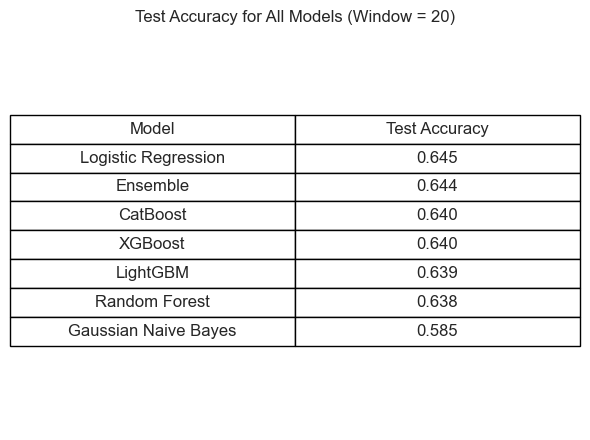

In [61]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# ─── 1) Point this to wherever your "*_window_results_summary.csv" files are ───
name_map = {
    'catboost': 'CatBoost',
    'gnb':      'Gaussian Naive Bayes',
    'lgbm':     'LightGBM',
    'lr':       'Logistic Regression',
    'rf':       'Random Forest',
    'stack':    'Ensemble',
    'xgb':      'XGBoost'
}

SUMMARY_DIR = os.path.join(DATA_PATH, 'prediction_results')

# ─── 2) Grab all summary files ───────────────────────────────────────────────
pattern = os.path.join(SUMMARY_DIR, '*_window_results_summary.csv')
files   = glob.glob(pattern)

# ─── 3) Extract the accuracy for window=20 from each model ──────────────────
records = []
for fp in files:
    model = os.path.basename(fp).replace('_window_results_summary.csv','')
    full_name = name_map.get(model, model)
    df    = pd.read_csv(fp)
    if 'window' not in df.columns or 'accuracy_test' not in df.columns:
        continue
    df['window'] = df['window'].astype(int)
    sel = df.loc[df['window']==20, 'accuracy_test']
    if not sel.empty:
        records.append({
            'Model': full_name,
            'Test Accuracy': f"{sel.iloc[0]:.3f}"
        })

df20 = pd.DataFrame(records).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)


# ─── 4) Plot it as a matplotlib table ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, len(df20)*0.5 + 1))
ax.axis('off')

tbl = ax.table(
    cellText=df20.values.tolist(),
    colLabels=df20.columns.tolist(),
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1, 1.5)

plt.title('Test Accuracy for All Models (Window = 20)')
plt.tight_layout()
plt.savefig('Test_Accuracy_20_avg.png',
            dpi=300,
            bbox_inches='tight',
            transparent=False,
            format='png')
plt.show()

In [31]:
# 1) Filter for only the lr entries
df_lr = df_acc[df_acc['model'] == 'lr'].copy()

# 2a) If you want them sorted by window:
df_lr_by_window = df_lr.sort_values('window').reset_index(drop=True)
print("LR accuracy by rolling window:")
print(df_lr_by_window[['window','accuracy_test']].to_string(index=False))

# 2b) Or if you’d rather rank them by test accuracy:
df_lr_ranked = df_lr.sort_values('accuracy_test', ascending=False).reset_index(drop=True)
df_lr_ranked['rank'] = df_lr_ranked['accuracy_test']\
    .rank(method='dense', ascending=False).astype(int)
print("\nLR models ranked by accuracy:")
print(df_lr_ranked[['rank','window','accuracy_test']].to_string(index=False))

LR accuracy by rolling window:
 window  accuracy_test
      1       0.598980
      3       0.613481
      5       0.619955
     10       0.636432
     15       0.638084
     20       0.645012
     30       0.655565

LR models ranked by accuracy:
 rank  window  accuracy_test
    1      30       0.655565
    2      20       0.645012
    3      15       0.638084
    4      10       0.636432
    5       5       0.619955
    6       3       0.613481
    7       1       0.598980


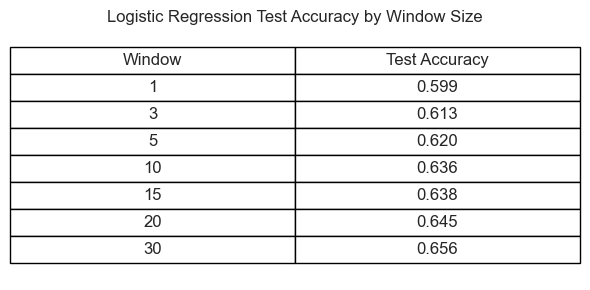

In [60]:
import os
import pandas as pd
import matplotlib.pyplot as plt

lr_file =  os.path.join(DATA_PATH, 'prediction_results/lr_window_results_summary.csv')
df_lr = pd.read_csv(lr_file)

df_lr['window'] = df_lr['window'].astype(int)
df_lr['accuracy_test'] = df_lr['accuracy_test'].map(lambda x: f"{x:.3f}")

cell_text = df_lr[['window','accuracy_test']]\
    .astype(str)\
    .values.tolist()

fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')

tbl = ax.table(
    cellText=cell_text,
    colLabels=['Window', 'Test Accuracy'],
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1, 1.5)

plt.title('Logistic Regression Test Accuracy by Window Size')
plt.tight_layout()
plt.savefig('Window_Sizes_Test_Accuracy.png',
            dpi=300,
            bbox_inches='tight',
            transparent=False,
            format='png')
plt.show()

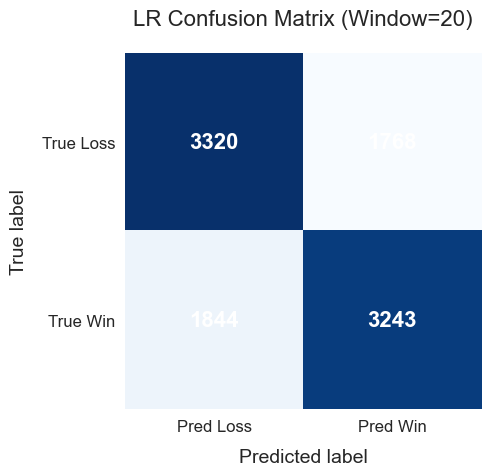

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix


# Plot Confusion matrix of lr model
lr_20 = window_results[20]['tuning_results']
cm = lr_20['confusion_matrix_test']  # your existing 2×2 array

fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.grid(False)
ax.set_aspect('equal')

# tick labels
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Pred Loss','Pred Win'], fontsize=12)
ax.set_yticklabels(['True Loss','True Win'], fontsize=12)

# remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# cell annotations
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha='center', va='center',
            fontsize=16, fontweight='bold',
            color='white' if cm[i, j] > thresh else 'black'
        )

# labels & title
ax.set_xlabel('Predicted label', fontsize=14, labelpad=10)
ax.set_ylabel('True label',      fontsize=14, labelpad=10)
ax.set_title('LR Confusion Matrix (Window=20)', fontsize=16, pad=20)

plt.tight_layout()
plt.savefig('Confusion_Matrix.png',
            dpi=300,
            bbox_inches='tight',
            transparent=False,
            format='png')
plt.show()